# 1.1 Your First StateGraph (Nodes & Edges)

**Learning:** [1.1 First StateGraph](../../../Learning/LangGraph/01_beginner/1.1_first_stategraph.md)

**Goal:** Build graphs with explicit nodes and edges, run them with `invoke()`, visualize structure, and stream node execution.

**Prerequisite:** Complete `00_foundations/0.0_graph_sanity_check.ipynb`

## Setup

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

## 1. Minimal graph — one node

Flow: `START → greet → END`

This matches the roadmap example. Each line builds one piece of the graph.

In [3]:
class State(TypedDict):
    message: str  # shared field passed between nodes


def greet(state: State) -> State:
    # Node reads state, returns partial update (only changed fields)
    return {"message": f"Hello, {state['message']}!"}


graph = StateGraph(State)       # 1. create builder with state schema
graph.add_node("greet", greet)  # 2. register node function
graph.add_edge(START, "greet")  # 3. entry: START always goes to greet
graph.add_edge("greet", END)    # 4. exit: after greet, stop

app = graph.compile()           # 5. freeze into runnable app
app.invoke({"message": "LangGraph"})  # 6. run once

{'message': 'Hello, LangGraph!'}

## 2. Multi-node pipeline — state flows through steps

Flow: `START → trim → uppercase → END`

Each node updates the same `message` field. LangGraph merges updates automatically.

In [4]:
class PipelineState(TypedDict):
    message: str
    steps_run: int  # track how many nodes executed (useful for debugging)


def trim_node(state: PipelineState) -> PipelineState:
    return {
        "message": state["message"].strip(),
        "steps_run": state.get("steps_run", 0) + 1,
    }


def uppercase_node(state: PipelineState) -> PipelineState:
    return {
        "message": state["message"].upper(),
        "steps_run": state["steps_run"] + 1,
    }


pipeline = StateGraph(PipelineState)
pipeline.add_node("trim", trim_node)
pipeline.add_node("uppercase", uppercase_node)
pipeline.add_edge(START, "trim")
pipeline.add_edge("trim", "uppercase")  # fixed edge: trim always → uppercase
pipeline.add_edge("uppercase", END)

pipeline_app = pipeline.compile()
pipeline_app.invoke({"message": "  langgraph  ", "steps_run": 0})

{'message': 'LANGGRAPH', 'steps_run': 2}

## 3. Visualize the graph (Mermaid)

Mermaid text is always available. Paste into [mermaid.live](https://mermaid.live) or docs.

In [5]:
print(pipeline_app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	trim(trim)
	uppercase(uppercase)
	__end__([<p>__end__</p>]):::last
	__start__ --> trim;
	trim --> uppercase;
	uppercase --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



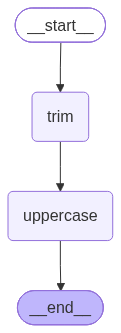

In [6]:
# Optional: render PNG in notebook (needs network for mermaid.ink)
from IPython.display import Image, display

try:
    display(Image(pipeline_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG render skipped: {e}")
    print("Use the Mermaid text above instead.")

## 4. Stream node execution

`stream()` emits state after **each node** completes — useful for debugging and progress UIs.

In [7]:
for step in pipeline_app.stream({"message": "  hello  ", "steps_run": 0}):
    # Each `step` is a dict: {node_name: state_snapshot}
    print(step)

{'trim': {'message': 'hello', 'steps_run': 1}}
{'uppercase': {'message': 'HELLO', 'steps_run': 2}}


## 5. Inspect graph structure

Before running, you can inspect registered nodes and edges programmatically.

In [ ]:
g = pipeline_app.get_graph()
print("Nodes:", list(g.nodes.keys()))
print("Edges:", g.edges)

## Exit Criteria Checklist

- [ ] Built `START → greet → END` and got `Hello, LangGraph!`
- [ ] Built a multi-node pipeline where state passed through `trim` then `uppercase`
- [ ] Printed a Mermaid diagram of your graph
- [ ] Used `stream()` and saw one event per node
- [ ] Can explain: node = function, edge = transition, compile = make runnable

**Next:** [1.2 Typed State](../../../Learning/LangGraph/01_beginner/1.2_typed_state.md) → `1.2_typed_state.ipynb`